exp 11

Actual: ['Good' 'Good' 'Excellent']
Predicted: ['Good' 'Good' 'Excellent']
Accuracy: 1.0
Predicted Credit Category: Good


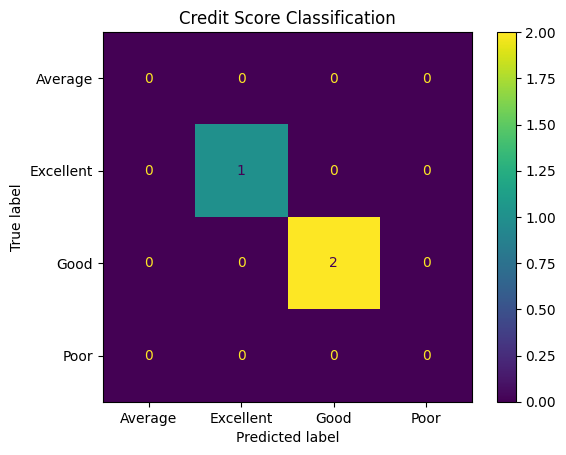

In [11]:
# EXPERIMENT 11
# Credit Score Classification using Decision Tree

import numpy as np
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

# Dataset
X = np.array([
    [12, 10, 1, 1],
    [10, 8, 2, 1],
    [8, 6, 2, 1],
    [6, 4, 3, 0],
    [4, 2, 4, 0],
    [15, 12, 1, 1],
    [7, 5, 3, 1],
    [5, 3, 4, 0],
    [11, 9, 2, 1],
    [3, 1, 5, 0]
])

y = np.array([
    "Excellent",
    "Good",
    "Good",
    "Average",
    "Poor",
    "Excellent",
    "Average",
    "Poor",
    "Good",
    "Poor"
])

encoder = LabelEncoder()
y_encoded = encoder.fit_transform(y)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_encoded,
    test_size=0.3,
    random_state=42
)

model = DecisionTreeClassifier(
    criterion="entropy",
    random_state=42
)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Actual:", encoder.inverse_transform(y_test))
print("Predicted:", encoder.inverse_transform(y_pred))
print("Accuracy:", accuracy_score(y_test, y_pred))

new_customer = np.array([[9, 7, 2, 1]])
prediction = model.predict(new_customer)

print("Predicted Credit Category:",
      encoder.inverse_transform(prediction)[0])

# Fix: Ensure confusion matrix considers all possible classes
cm = confusion_matrix(y_test, y_pred, labels=np.arange(len(encoder.classes_)))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=encoder.classes_
)

disp.plot()
plt.title("Credit Score Classification")
plt.show()